In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

In [ ]:
# Exercise 8.8
# Simulating European call and down-and-out hedges to observe quality
def black_scholes_call(S, K, r, sigma, q, T):
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call = np.exp(-q*T)*S*norm.cdf(d1) - np.exp(-r*T)*K*norm.cdf(d2)

    return call

def simulate_asset_price(S, r, sigma, q, T, simulations):
    drift = (r - q - 0.5 * sigma**2) * T
    shock = sigma * np.sqrt(T) * np.random.randn(int(simulations))
    prices = S * np.exp(drift + shock)
    return prices

def hedge_cost_european_call(S, K, r, sigma, T, end_prices):
    call_payoff = np.maximum(end_prices - K, 0)
    initial_call_price = black_scholes_call(S, K, r, sigma, q, T)
    call_cost = initial_call_price * np.exp(r * T)  # Future value of option price
    costs = np.maximum(end_prices - call_payoff, 0) + call_cost
    return costs

def hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations):
    knock_out_path = simulate_asset_price(S, r, sigma, q, T, simulations)
    knock_out = np.any(knock_out_path < barrier)

    down_out_call_payoff = np.where(knock_out, 0, np.maximum(end_prices - K, 0))
    initial_call_price = black_scholes_call(S, K, r, sigma, q, T)  # Price assuming no knock-out
    call_cost = initial_call_price * np.exp(r * T)  # Future value of option price
    costs = np.maximum(end_prices - down_out_call_payoff, 0) + call_cost
    return costs

def compare_hedges_end_of_year(S, r, sigma, q, simulations=500):
    T = 1  
    K = S  # At-the-money strike price
    barrier = S * 0.9  # Knock-out barrier 10% below initial price

    # Simulate end-of-year asset prices
    end_prices = simulate_asset_price(S, r, sigma, q, T, simulations)

    # Calculate costs for each hedging strategy
    costs_standard_call = hedge_cost_european_call(S, K, r, sigma, T, end_prices)
    costs_down_and_out_call = hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations)

    plt.figure(figsize=(14, 6))
    plt.hist(costs_standard_call, bins=30, alpha=0.5, label='European Call Hedge', color='blue')
    plt.hist(costs_down_and_out_call, bins=30, alpha=0.5, label='Down-and-Out Call Hedge', color='green')
    plt.xlabel("End-of-Year Cost")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Comparison of End-of-Year Costs for Hedging Strategies")
    plt.grid(True)
    plt.show()

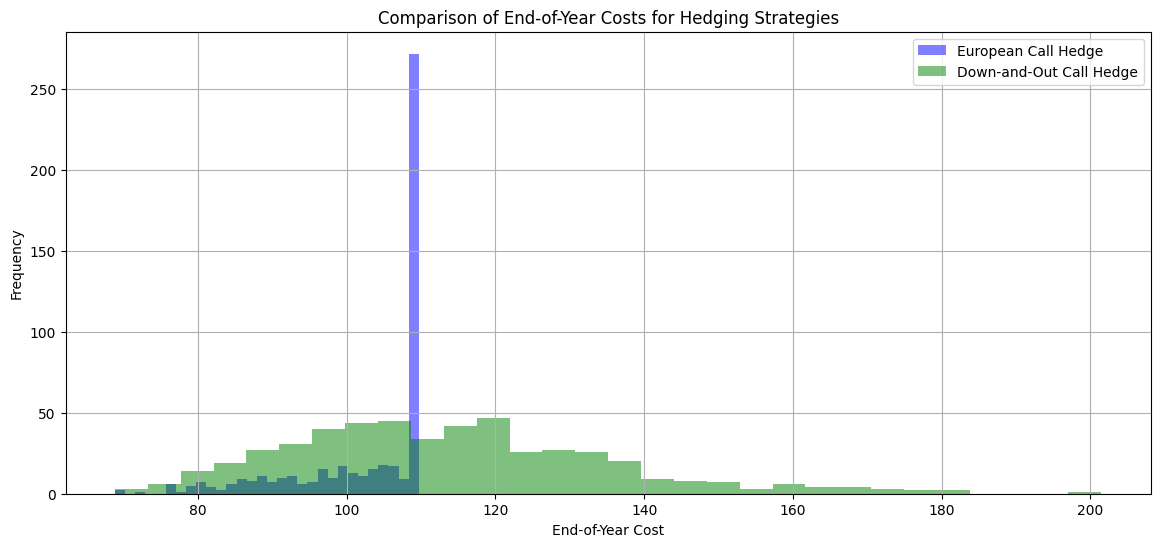

In [3]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
q = 0.02
simulations = 500

compare_hedges_end_of_year(S, r, sigma, q, simulations)

In [ ]:
# Exercise 8.9
## Adding a down-and-in call to the previous problem
## First, need to reset the functions from 8.7 since we changed them
## black_scholes_call and simulate_asset_price should be okay

def hedge_cost_european_call(S, K, r, sigma, T, end_prices):
    call_payoff = np.maximum(end_prices - K, 0)
    costs = np.maximum(end_prices - call_payoff, 0)
    return costs

def hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations=500):
    knock_out_path = simulate_asset_price(S, r, sigma, q, T, simulations)
    knock_out = np.any(knock_out_path < barrier)
    down_out_call_payoff = np.where(knock_out, 0, np.maximum(end_prices - K, 0))
    costs = np.maximum(end_prices - down_out_call_payoff, 0)
    return costs

def hedge_cost_combined_call(S, K, r, sigma, T, barrier, end_prices, simulations=500):
    """
    Cost calculation for a combination of down-and-out and down-and-in calls.
    """
    knock_out_path = simulate_asset_price(S, r, sigma, q, T, simulations)
    knock_out = np.any(knock_out_path < barrier)

    # Down-and-out payoff
    down_out_call_payoff = np.where(knock_out, 0, np.maximum(end_prices - K, 0))

    # Down-and-in payoff (strike is 10% below S if the barrier is hit)
    new_strike = 0.9 * S
    down_in_call_payoff = np.where(knock_out, np.maximum(end_prices - new_strike, 0), 0)

    # Combined payoff
    combined_call_payoff = down_out_call_payoff + down_in_call_payoff
    costs = np.maximum(end_prices - combined_call_payoff, 0)
    return costs

def compare_hedges(S, r, sigma, q, simulations=500):
    """
    Perform simulations and create histograms for three hedges:
    1. European call
    2. Down-and-out call
    3. Combination of down-and-out and down-and-in calls
    """
    T = 1  # One-year maturity
    K = S  # At-the-money strike price
    barrier = S * 0.9  # Knock-out barrier 10% below initial price

    # Simulate end-of-year asset prices
    end_prices = simulate_asset_price(S, r, sigma, q, T, simulations)

    # Calculate costs for each hedging strategy
    costs_european_call = hedge_cost_european_call(S, K, r, sigma, T, end_prices)
    costs_down_and_out_call = hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations)
    costs_combined_call = hedge_cost_combined_call(S, K, r, sigma, T, barrier, end_prices, simulations)

    # Plot histograms to compare costs
    plt.figure(figsize=(14, 8))
    plt.hist(costs_european_call, bins=30, alpha=0.5, label='European Call Hedge', color='blue')
    plt.hist(costs_down_and_out_call, bins=30, alpha=0.5, label='Down-and-Out Call Hedge', color='green')
    plt.hist(costs_combined_call, bins=30, alpha=0.5, label='Combined Hedge (Down-and-Out + Down-and-In)', color='orange')
    plt.xlabel("End-of-Year Cost")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Comparison of End-of-Year Costs for Hedging Strategies")
    plt.grid(True)
    plt.show()

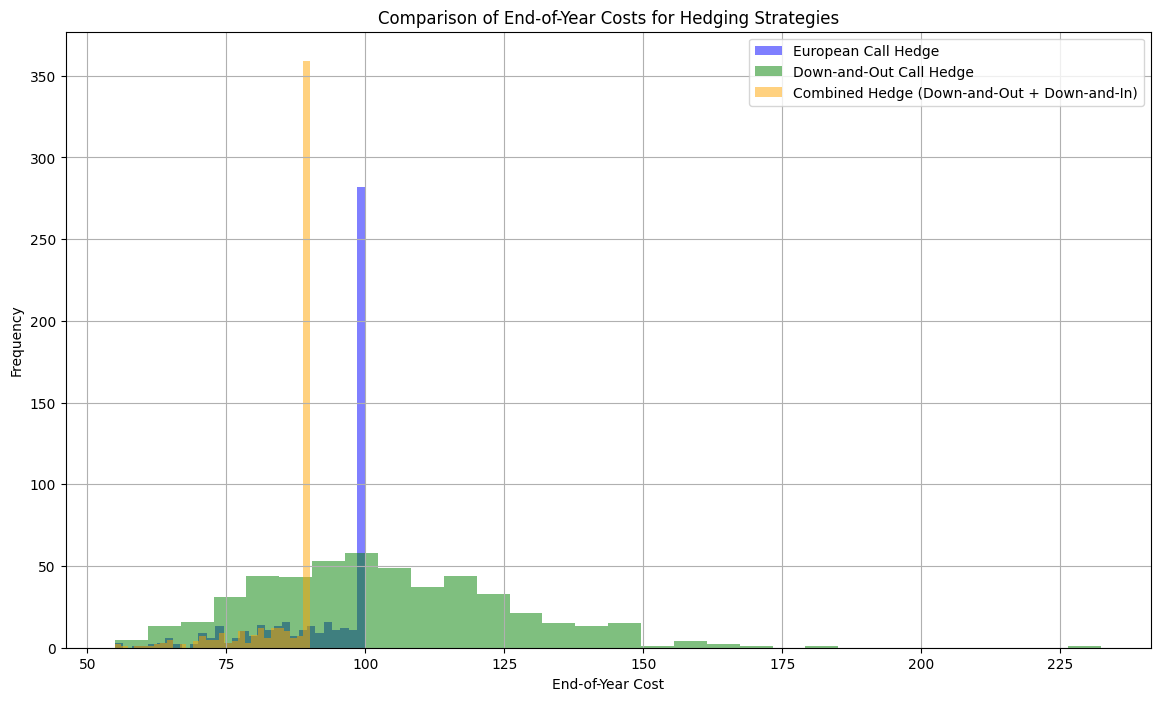

In [5]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
q = 0.02
simulations = 500

compare_hedges(S, r, sigma, q, simulations)

In [ ]:
# Exercise 8.10
## now adding previous option to the comparison in 8.8
## Need to reset each again
def hedge_cost_european_call(S, K, r, sigma, T, end_prices):
    call_payoff = np.maximum(end_prices - K, 0)
    initial_call_price = black_scholes_call(S, K, r, sigma, q, T)
    call_cost = initial_call_price * np.exp(r * T)  # Future value of option price
    costs = np.maximum(end_prices - call_payoff, 0) + call_cost
    return costs

def hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations):
    knock_out_path = simulate_asset_price(S, r, sigma, q, T, simulations)
    knock_out = np.any(knock_out_path < barrier)

    down_out_call_payoff = np.where(knock_out, 0, np.maximum(end_prices - K, 0))
    initial_call_price = black_scholes_call(S, K, r, sigma, q, T)  # Price assuming no knock-out
    call_cost = initial_call_price * np.exp(r * T)  # Future value of option price
    costs = np.maximum(end_prices - down_out_call_payoff, 0) + call_cost
    return costs

def hedge_cost_down_and_in_call(S, K, r, sigma, T, barrier, end_prices):

    european_call_price = black_scholes_call(S, K, r, sigma, 0, T)

    down_and_out_price = black_scholes_call(S, K, r, sigma, 0, T) - np.exp(-r * T) * max(0, barrier - S)

    down_and_in_price = european_call_price - down_and_out_price

    # Simulate knock-in path
    knock_in_path = simulate_asset_price(S, r, sigma, q, T, simulations=500)
    knock_in = np.any(knock_in_path < barrier)

    down_in_call_payoff = np.where(knock_in, np.maximum(end_prices - K, 0), 0)

    cost = down_and_in_price * np.exp(r * T)
    costs = np.maximum(end_prices - down_in_call_payoff, 0) + cost
    return costs

def hedge_cost_combined_call(S, K, r, sigma, T, barrier, end_prices):
    """
    Cost calculation for a combination of down-and-out and down-and-in calls.
    """
    down_out_costs = hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations)
    down_in_costs = hedge_cost_down_and_in_call(S, K, r, sigma, T, barrier, end_prices)

    # Combined costs
    combined_costs = down_out_costs + down_in_costs
    return combined_costs


def compare_hedges_end_of_year(S, r, sigma, q, simulations):
    """
    Compare hedging strategies using end-of-year costs for:
    1. European call
    2. Down-and-out call
    3. Combination of down-and-out and down-and-in calls
    """
    T = 1  
    K = S  # At-the-money strike price
    barrier = S * 0.9  # Knock-out barrier 10% below initial price

    # Simulate end-of-year asset prices
    end_prices = simulate_asset_price(S, r, sigma, q, T, simulations)

    # Calculate costs for each hedging strategy
    costs_european_call = hedge_cost_european_call(S, K, r, sigma, T, end_prices)
    costs_down_and_out_call = hedge_cost_down_and_out_call(S, K, r, sigma, T, barrier, end_prices, simulations)
    costs_combined_call = hedge_cost_combined_call(S, K, r, sigma, T, barrier, end_prices)

    plt.figure(figsize=(14, 8))
    plt.hist(costs_european_call, bins=30, alpha=0.5, label='European Call Hedge', color='blue')
    plt.hist(costs_down_and_out_call, bins=30, alpha=0.5, label='Down-and-Out Call Hedge', color='green')
    plt.hist(costs_combined_call, bins=30, alpha=0.5, label='Combined Hedge (Down-and-Out + Down-and-In)', color='orange')
    plt.xlabel("End-of-Year Cost")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Comparison of End-of-Year Costs for Hedging Strategies")
    plt.grid(True)
    plt.show()

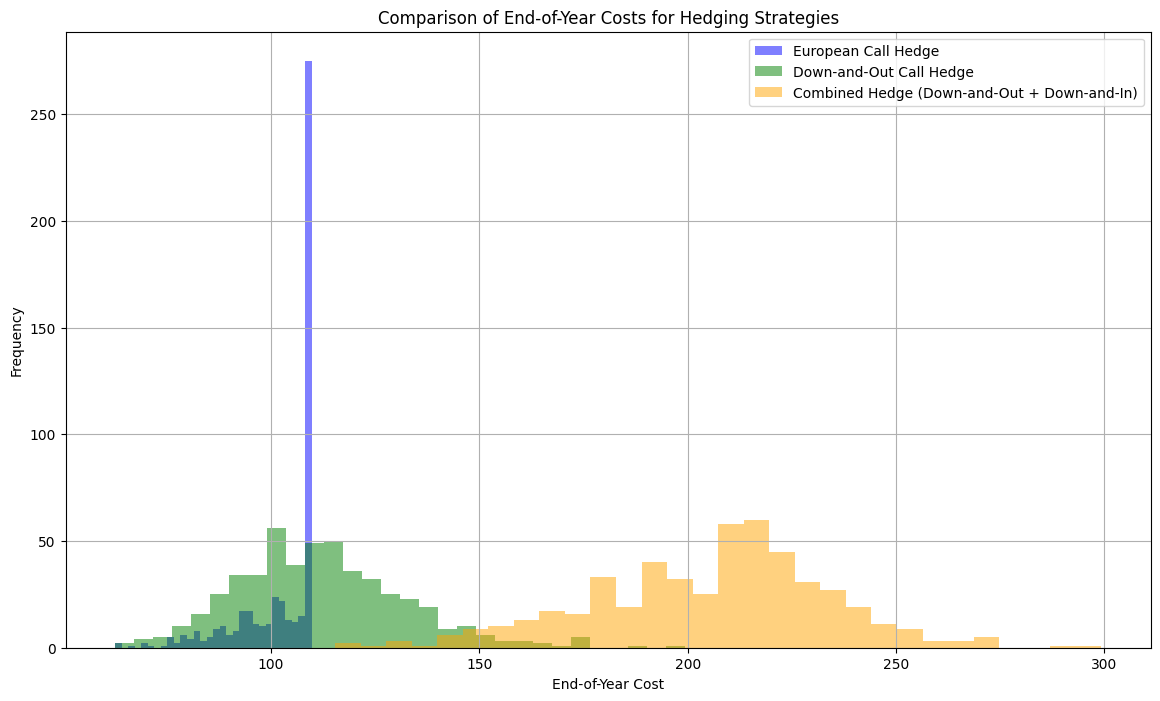

In [19]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
q = 0.02
simulations = 500

compare_hedges_end_of_year(S, r, sigma, q, simulations)

In [ ]:
# Exercise 8.11
# Each week you purchase 100 units of an asset, and you want to hedge your total quarterly (13-week) cost.
def simulate_asset_prices(S, r, sigma, q, T, steps, simulations):
    dt = T / steps
    prices = np.zeros((simulations, steps + 1))
    prices[:, 0] = S
    for t in range(1, steps + 1):
        drift = (r - q - 0.5*sigma**2) * dt
        shock = sigma * np.sqrt(dt) * np.random.randn(simulations)
        prices[:, t] = prices[:, t - 1] * np.exp(drift + shock)
    return prices

# (a) First hedge: standard European call maturing at the end of the quarter (T = 0.25) on 1300 units of the asset
def hedge_single_call(S, K, r, sigma, q, T, end_prices):
    call_payoff = np.maximum(end_prices - K, 0) * 1300  # 1300 units
    call_cost = black_scholes_call(S, K, r, sigma, q, T) * 1300
    costs = call_cost * np.exp(r * T) - call_payoff
    return costs

# (b) Second hedge: 13 call options maturing at the end of each week of the quarter, each written on 100 unites of the asset
def hedge_weekly_calls(S, K, r, sigma, q, T, weekly_prices):
    weekly_cost = 0
    weekly_payoff = 0
    dt = T / 13
    for t in range(1, 14):  # Weekly options
        weekly_payoff += np.maximum(weekly_prices[:, t] - K, 0) * 100
        weekly_cost += black_scholes_call(S, K, r, sigma, q, dt) * 100 * np.exp(r * t * dt)
    costs = weekly_cost - weekly_payoff
    return costs

# (c) Third hedge: discretely sampled avg-price call with maturity T = 0.25 written on 1300 units of the asset, sampling at end of each week 
def hedge_arithmetic_average_call(S, K, r, sigma, q, T, weekly_prices):
    arithmetic_avg = np.mean(weekly_prices[:, 1:], axis=1)
    call_payoff = np.maximum(arithmetic_avg - K, 0) * 1300
    avg_cost = black_scholes_call(S, K, r, sigma / np.sqrt(13), q, T) * 1300
    costs = avg_cost * np.exp(r * T) - call_payoff
    return costs

# (d) Fourth hedge: discretely sampled geometric-avg-price call with maturity T = 0.25 written on 1300 units of the asset, sampling at the end of each week
def hedge_geometric_average_call(S, K, r, sigma, q, T, weekly_prices):
    geometric_avg = np.exp(np.mean(np.log(weekly_prices[:, 1:]), axis=1))
    call_payoff = np.maximum(geometric_avg - K, 0) * 1300
    avg_cost = black_scholes_call(S, K, r, sigma / np.sqrt(13), q, T) * 1300
    costs = avg_cost * np.exp(r * T) - call_payoff
    return costs

def compare_quarterly_hedges(S, r, sigma, q, simulations):
    T = 0.25  # Quarter (13 weeks)
    K = S  # At-the-money strike price
    steps = 13  # Weekly sampling

    # Simulate asset prices
    prices = simulate_asset_prices(S, r, sigma, q, T, steps, simulations)
    end_prices = prices[:, -1]

    # Calculate costs for each hedging strategy
    costs_single_call = hedge_single_call(S, K, r, sigma, q, T, end_prices)
    costs_weekly_calls = hedge_weekly_calls(S, K, r, sigma, q, T, prices)
    costs_arithmetic_avg = hedge_arithmetic_average_call(S, K, r, sigma, q, T, prices)
    costs_geometric_avg = hedge_geometric_average_call(S, K, r, sigma, q, T, prices)

    plt.figure(figsize=(14, 8))
    plt.hist(costs_single_call, bins=30, alpha=0.5, label='Single European Call', color='blue')
    plt.hist(costs_weekly_calls, bins=30, alpha=0.5, label='Weekly Calls', color='green')
    plt.hist(costs_arithmetic_avg, bins=30, alpha=0.5, label='Arithmetic Avg Call', color='orange')
    plt.hist(costs_geometric_avg, bins=30, alpha=0.5, label='Geometric Avg Call', color='red')
    plt.xlabel("End-of-Quarter Cost")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Comparison of Quarterly Hedging Strategies")
    plt.grid(True)
    plt.show()

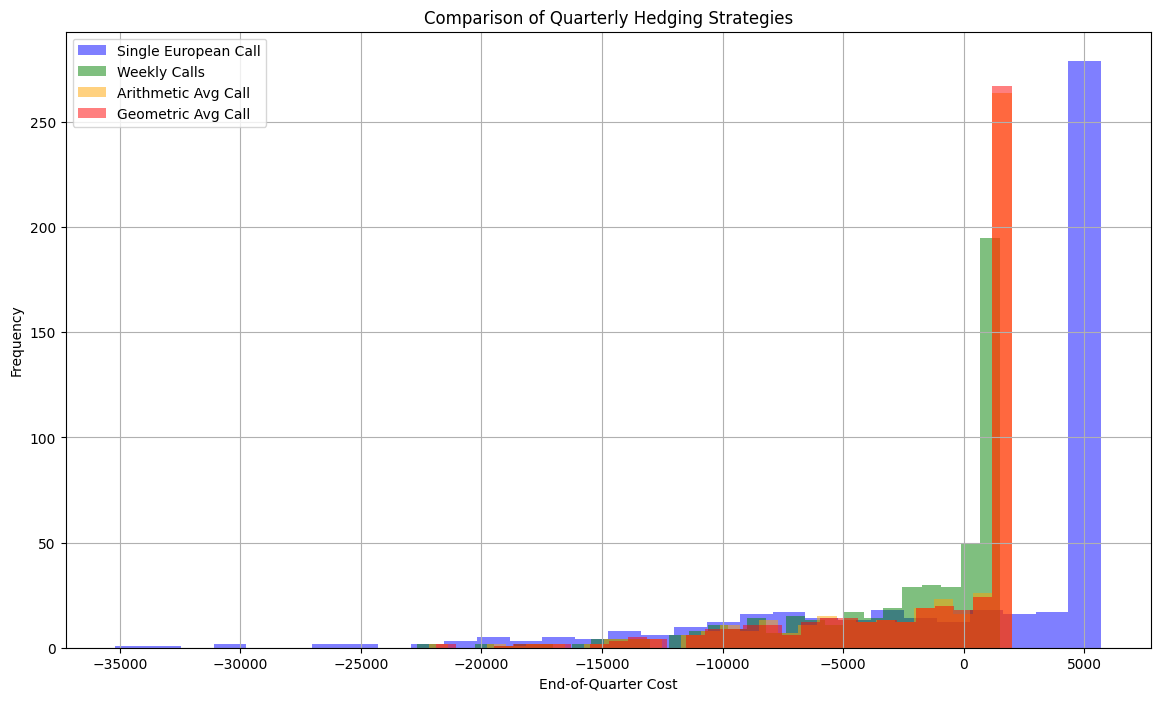

In [23]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
q = 0.02
simulations = 500

compare_quarterly_hedges(S, r, sigma, q, simulations)

In [ ]:
# Exercise 8.12
## pricing the options for the previous problem and adding the costs to the comparison
def compute_option_prices(S, r, sigma, q, T):
    # (a)
    single_call_price = black_scholes_call(S, S, r, sigma, q, T) * 1300  # 1300 units

    # (b)
    weekly_call_price = 0
    dt = T / 13
    for t in range(1, 14):
        weekly_call_price += black_scholes_call(S, S, r, sigma, q, dt) * 100  # 100 units each week

    # (d)
    geom_avg_vol = sigma / np.sqrt(13)
    geom_avg_call_price = black_scholes_call(S, S, r, geom_avg_vol, q, T) * 1300  # 1300 units

    return single_call_price, weekly_call_price, geom_avg_call_price

def compare_hedges_with_costs(S, r, sigma, q, simulations):
    T = 0.25  # Quarter (13 weeks)
    K = S  # At-the-money strike price
    steps = 13  # Weekly sampling

    # Compute options prices 
    single_call_price, weekly_call_price, geom_avg_call_price = compute_option_prices(S, r, sigma, q, T)

    # Future values of prices
    fv_single_call = single_call_price * np.exp(r * T)
    fv_weekly_call = weekly_call_price * np.exp(r * T)
    fv_geom_avg_call = geom_avg_call_price * np.exp(r * T)

    prices = simulate_asset_prices(S, r, sigma, q, T, steps, simulations)
    end_prices = prices[:, -1]

    # Hedging costs for each strategy
    costs_single_call = hedge_single_call(S, K, r, sigma, q, T, end_prices) + fv_single_call
    costs_weekly_calls = hedge_weekly_calls(S, K, r, sigma, q, T, prices) + fv_weekly_call
    costs_geom_avg_call = hedge_geometric_average_call(S, K, r, sigma, q, T, prices) + fv_geom_avg_call

    plt.figure(figsize=(14, 8))
    plt.hist(costs_single_call, bins=30, alpha=0.5, label='Single European Call', color='blue')
    plt.hist(costs_weekly_calls, bins=30, alpha=0.5, label='Weekly Calls', color='green')
    plt.hist(costs_geom_avg_call, bins=30, alpha=0.5, label='Geometric Avg Call', color='orange')
    plt.xlabel("End-of-Quarter Cost")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Comparison of Quarterly Hedging Strategies (Including Option Costs)")
    plt.grid(True)
    plt.show()

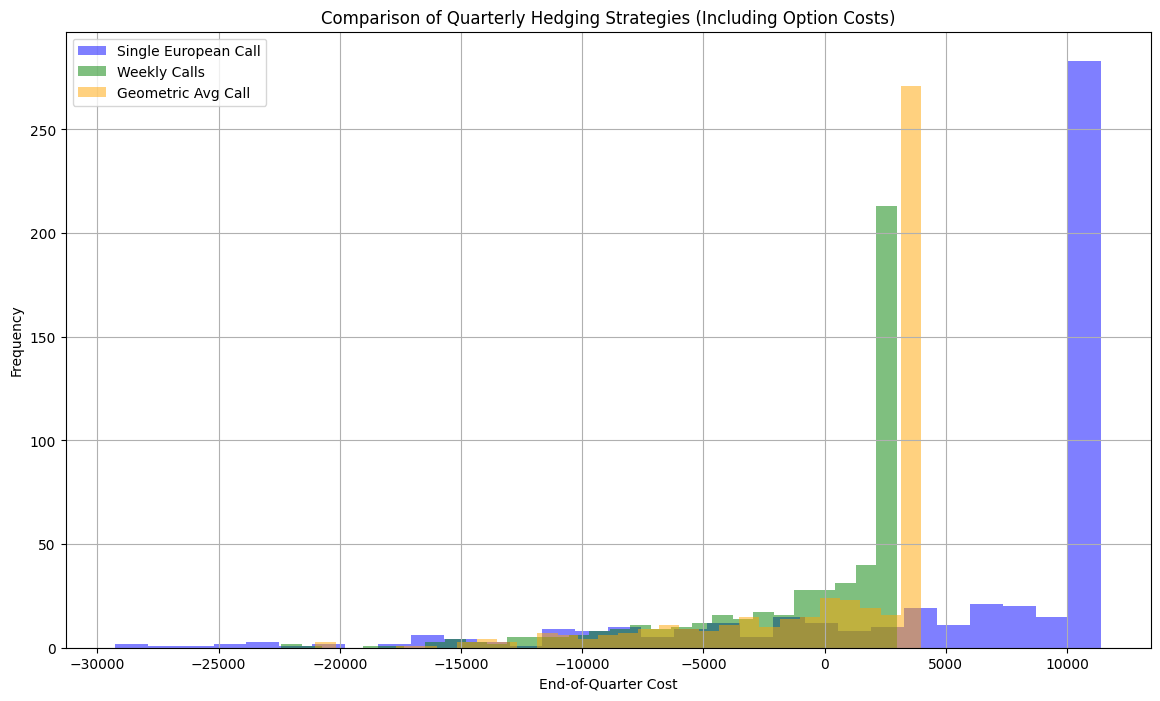

In [25]:
# Set parameters
S = 100
r = 0.05
sigma = 0.2
q = 0.02
simulations = 500

compare_hedges_with_costs(S, r, sigma, q, simulations)

In [ ]:
# Exercise 9.1
# Price a floating-strike call using Monte Carlo simulation
def monte_carlo_floating_strike_call(S, r, sigma, q, T, N, M, use_antithetic=False):
    """  
    Compute the value of a floating strike call option using Monte Carlo simulation
    """

    dt = T / N
    drift = (r - q - 0.5*sigma**2) * dt
    vol = sigma * np.sqrt(dt)

    Z = np.random.randn(M, N)
    if use_antithetic:
        Z = np.concatenate([Z, -Z], axis=0)
        M *= 2  # Adjust number of paths to account for this

    S_paths = np.zeros((M, N+1))
    S_paths[:, 0] = S
    for t in range(1, N+1):
        S_paths[:, t] = S_paths[:, t-1] * np.exp(drift + vol * Z[:, t-1])

    S_avg = np.mean(S_paths[:, :-1], axis=1)
    payoff = np.maximum(S_paths[:, -1] - S_avg, 0)

    discounted_payoff = np.exp(-r * T) * payoff
    price = np.mean(discounted_payoff)
    std_error = np.std(discounted_payoff) / np.sqrt(M)

    return price, std_error

In [31]:
# Set parameters 
S = 100
r = 0.05
sigma = 0.2
q = 0.02
T = 1
N = 252 
M = 10000

price_no_antith, se_no_antith = monte_carlo_floating_strike_call(S, r, sigma, q, T, N, M, use_antithetic=False)
price_with_antith, se_with_antith = monte_carlo_floating_strike_call(S, r, sigma, q, T, N, M, use_antithetic=True)

print('Price, Std Error without Antithetic Variate', price_no_antith, se_no_antith)
print('Price, Std Error with Antithetic Variate', price_with_antith, se_with_antith)

Price, Std Error without Antithetic Variate 5.206773669587261 0.0804116156387204
Price, Std Error with Antithetic Variate 5.256106386719256 0.057539667726873425


In [ ]:
# Exercise 9.2
# Price an American put option with a binomial model
def american_put_binomial(S0, K, r, sigma, q, T, N):
    """  
    Compute the value of an American put option using the binomial model
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    pu = (np.exp((r - q) * dt) - d) / (u - d)
    
    # Discount pu, pd
    dpu = np.exp(-r * dt) * pu
    dpd = np.exp(-r * dt) * (1 - pu)

    # Initialize option values at maturity
    S = S0 * d ** np.arange(N, -1, -1)
    put_values = np.maximum(K - S, 0)

    # Backward induction
    for i in range(N - 1, -1, -1):
        S = S0 * d ** np.arange(i, -1, -1)
        for j in range(i + 1):
            hold_value = dpd * put_values[j] + dpu * put_values[j + 1]
            exercise_value = K - S[j]
            put_values[j] = max(hold_value, exercise_value)

    return put_values[0]

def american_put_binomial_bs_re(S0, K, r, sigma, q, T, N):
    """  
    Compute the Richardson extrapolated value of an American put option using the binomial model
    """
    if N % 2 != 0:
        raise ValueError("Number of periods must be a multiple of two for this function.")
    
    y2 = american_put_binomial(S0, K, r, sigma, q, T, N)
    y1 = american_put_binomial(S0, K, r, sigma, q, T, N // 2)

    return 2 * y2 - y1

def compare_american_puts(S0, K, r, sigma, q, T, N_values, N_ref):
    """  
    Compare the estimates of hte value of an American put for various N wiht a reference value
    """
    ref_value = american_put_binomial(S0, K, r, sigma, q, T, N_ref)
    print("Binomial Tree Reference Value:", ref_value)

    # Compare estimates at various N
    for N in N_values:
        estimate = american_put_binomial(S0, K, r, sigma, q, T, N)
        re_estimate = american_put_binomial_bs_re(S0, K, r, sigma, q, T, N)
        print("N:", N)
        print("Binomial:", estimate, "BS RE:", re_estimate)

In [38]:
# Set parameters
S0 = 100
K = 100
r = 0.05
sigma = 0.2
q = 0.02
T = 1
N_values = [10, 20, 40, 80, 160]
N_ref = 1000

compare_american_puts(S0, K, r, sigma, q, T, N_values, N_ref)

Binomial Tree Reference Value: 91.05599524049185
N: 10
Binomial: 25.09078679469708 BS RE: 31.888044552435964
N: 20
Binomial: 33.688991334437695 BS RE: 42.28719587417831
N: 40
Binomial: 44.07742800816864 BS RE: 54.46586468189958
N: 80
Binomial: 55.841802452703874 BS RE: 67.60617689723911
N: 160
Binomial: 68.00325665905169 BS RE: 80.1647108653995


In [ ]:
# Exercise 9.3
# Price an average-price call option
def average_price_call(S, K, r, sigma, T, N, q, M):
    """
    Compute the value of a discretely sampled average-price call option.
    """
    dt = T / N 
    discounted_payoff_sum = 0
    
    for _ in range(M):
        path = [S]
        for _ in range(N):
            # Simulate asset price using geometric Brownian motion
            dS = (r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * np.random.randn()
            path.append(path[-1] * np.exp(dS))
        
        # Compute payoff
        average_price = np.mean(path)
        payoff = max(average_price - K, 0)
        discounted_payoff_sum += payoff

    option_price = np.exp(-r * T) * discounted_payoff_sum / M
    return option_price

def simulate_quarterly_cost(S, r, sigma, q, T, K, N, M, weekly_purchase=100):
    """
    Simulate the end-of-quarter cost hedged using a discretely sampled average-price call.
    """
    # Price the average-price call option
    option_price = average_price_call(S, K, r, sigma, T, N, q, M)
    
    # Add interest on the option cost to put it on an end-of-quarter basis
    option_cost_with_interest = option_price * np.exp(r * T)

    # Simulate total end-of-quarter cost
    total_units = weekly_purchase * N
    drift = (r - q - 0.5 * sigma**2) * T
    shock = sigma * np.sqrt(T) * np.random.randn(M)
    end_prices = S * np.exp(drift + shock)
    
    # Average prices for hedging
    average_prices = [np.mean([S * np.exp((r - q - 0.5 * sigma**2) * (t / N) +
                                          sigma * np.sqrt(t / N) * np.random.randn()) for t in range(1, N + 1)])
                      for _ in range(M)]
    
    costs = []
    for avg_price, end_price in zip(average_prices, end_prices):
        total_cost = min(average_price_call(S, avg_price, r, sigma, T, N, q, M), end_price)
        costs.append(total_cost)
        
    end_of_quarter_cost = np.mean(costs) + option_cost_with_interest
    return end_of_quarter_cost

In [41]:
# Set parameters
S = 100
K = 100
r = 0.05
sigma = 0.2
q = 0.02
T = 0.25
N = 13
M = 1000

end_of_quarter_cost = simulate_quarterly_cost(S, r, sigma, q, T, K, N, M)
print(end_of_quarter_cost)

4.680445733149311


In [ ]:
# Exercise 9.4
# Price a European basket call option
def european_basket_call_binomial(S1, S2, K, r, sigma1, sigma2, rho, q1, q2, T, N):
    """  
    Value a European call option using a binomial tree
    """
    dt = T / N
    u1 = np.exp(sigma1 * np.sqrt(dt))
    d1 = 1 / u1
    u2 = np.exp(sigma2 * np.sqrt(dt))
    d2 = 1 / u2

    p1 = (np.exp((r - q1) * dt) - d1) / (u1 - d1)
    p2 = (np.exp((r - q2) * dt) - d2) / (u2 - d2)

    # Check to make sure probabilities are valid
    if not (0 <= p1 <= 1 and 0 <= p2 <= 1):
        raise ValueError("Invalid risk-neutral probabilities")
    
    discount = np.exp(-r * dt)

    # Initialize terminal node values
    basket_values = np.zeros((N + 1, N + 1))

    for i in range(N + 1):
        for j in range(N + 1):
            S1_T = S1 * (u1 ** i) * (d1 ** (N - i))
            S2_T = S2 * (u2 ** j) * (d2 ** (N - j))
            basket_price = 0.5 * (S1_T + S2_T)
            basket_values[i,j] = max(basket_price - K, 0)

    # Backward induction
    for step in range(N - 1, -1, -1):
        for i in range(step + 1):
            for j in range(step + 1):
                basket_values[i,j] = discount * (
                    p1 * p2 * basket_values[i+1, j+1]
                    + p1 * (1 - p2) * basket_values[i + 1, j]
                    + (1 - p1) * p2 * basket_values[i, j + 1]
                    + (1 - p1) * (1 - p2) * basket_values[i,j]
                )

    return basket_values[0,0]

In [43]:
# Set parameters
S1 = 100 
S2 = 120
K = 110
r = 0.05
sigma1 = 0.2
sigma2 = 0.25
rho = 0.3
q1 = 0.02
q2 = 0.03
T = 1
N = 100

basket_call_price = european_basket_call_binomial(S1, S2, K, r, sigma1, sigma2, rho, q1, q2, T, N)
print(basket_call_price)

8.312777352380895
